# Unsupervised Learning Project: A Reproducible Experimental Study of Clustering

**Team composition:** LuÃ­s Serrano (60253), Tiago Fonseca (72898), Miguel Teixeira (72922)

**Project title:** Guest Archetype Clustering in Hotel Booking


## Problem Framing
- **Q:** Do hotel bookings cluster into distinct guest profiles based on pre-arrival characteristics, and do these profiles exhibit consistent patterns in other booking dimensions?


## Segmentation Time and Eligibility Rule
- **Default segmentation time:** immediately after the initial booking is created.
- **Eligibility rule:** a variable enters the clustering inputs only if the hotel could know its value at that moment.
- **Allowed examples under this rule:** lead time, intended arrival period, stay length, party composition, market segment, distribution channel, deposit type, customer history and special requests recorded at booking.
- **Excluded from clustering inputs:** outcome/post-event variables such as `is_canceled`, `reservation_status`, `reservation_status_date`, as well as later operational fields such as `assigned_room_type`, `booking_changes` and `days_in_waiting_list`.
- **ADR decision:** ADR is kept out of the clustering inputs, so the main representation is a behavioural **noADR** segmentation; ADR is used later only for post-hoc profiling.


## Short Data Documentation
- **Dataset:** `hotel_bookings_course_release_v1.csv` (course release `v1`).
- **Source(s):** Kaggle listing + reference paper DOI + instructor snapshot URL from `DATASET_MANIFEST.yml`.
- **License/terms:** Kaggle listing states CC BY 4.0.
- **What each row represents:** one booking record.
- **Time span:** derived from `arrival_date_year` below.
- **Known quality issues:** missing data (`company`, `agent`, `country`, few in `children`), high-cardinality ID-like fields, and post-event leakage fields.


In [11]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path(".")
df = pd.read_csv(DATA_DIR / "hotel_bookings_course_release_v1.csv")

print("Dataset shape:", df.shape)
print("Columns:", len(df.columns))


Dataset shape: (119390, 32)
Columns: 32


## Final Include/Exclude Decisions for Clustering
- Keep only variables available at booking creation.
- Reserve `meal`, `adr`, and cancellation-related fields for post-hoc profiling.
- Replace raw `children` and `babies` with a combined family-composition feature to avoid treating family bookings as anomalies.


In [12]:
raw_clustering_features = [
    "hotel",
    "lead_time",
    "arrival_date_month",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "country",
    "market_segment",
    "distribution_channel",
    "is_repeated_guest",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "reserved_room_type",
    "deposit_type",
    "customer_type",
    "required_car_parking_spaces",
    "total_of_special_requests",
]

exclude_features = {
    "is_canceled": "Outcome/post-event leakage",
    "reservation_status": "Outcome/post-event leakage",
    "reservation_status_date": "Outcome/post-event leakage",
    "agent": "ID-like high-cardinality feature",
    "company": "ID-like high-cardinality feature with very high missingness",
    "assigned_room_type": "post-booking operational field",
    "booking_changes": "post-booking operational field",
    "days_in_waiting_list": "post-booking operational field",
    "arrival_date_year": "Redundant temporal context for this setup",
    "arrival_date_week_number": "Redundant temporal context for this setup",
    "arrival_date_day_of_month": "Redundant temporal context for this setup",
    "meal": "Reserved for post-hoc profiling",
    "adr": "Reserved for post-hoc profiling",
}

X = df[raw_clustering_features].copy()
posthoc_only = ["meal", "adr", "is_canceled", "reservation_status"]

print("Raw clustering feature count:", len(raw_clustering_features))
print("Excluded count:", len(exclude_features))
display(pd.DataFrame({"excluded_feature": list(exclude_features.keys()), "reason": list(exclude_features.values())}))


Raw clustering feature count: 19
Excluded count: 13


,excluded_feature,reason
0,is_canceled,Outcome/post-event leakage
1,reservation_status,Outcome/post-event leakage
2,reservation_status_date,Outcome/post-event leakage
3,agent,ID-like high-cardinality feature
4,company,ID-like high-cardinality feature with very hig...
5,assigned_room_type,post-booking operational field
6,booking_changes,post-booking operational field
7,days_in_waiting_list,post-booking operational field
8,arrival_date_year,Redundant temporal context for this setup
9,arrival_date_week_number,Redundant temporal context for this setup


## Representation Details
- `arrival_date_month` is not used as a raw integer. Instead, it is mapped into `arrival_season` as a coarse seasonality proxy that remains interpretable and avoids artificial Euclidean distances between month codes.
- `country` keeps `Portugal` and `Spain` as separate categories, while the remaining countries are grouped into broader `country_group` regions. Very small groups such as `North America`, `Middle East`, `Africa`, `Oceania`, and `Unknown` are merged into `Other` to reduce sparsity.
- `children` and `babies` are merged into `minor_count`, because the presence of minors is analytically meaningful for guest archetypes and should not be treated as an outlier.
- Extremely rare party-size values are top-coded (`adults` at 4+, `minor_count` at 3+) to reduce leverage from anomalous or highly exceptional records while keeping the family/group signal.
- `meal` and `adr` are kept outside the clustering matrix and used later for post-hoc interpretation.
- A future sensitivity extension could compare this coarse seasonality encoding against a finer cyclic month representation, but all models in the main analysis use the same representation for consistency.


In [13]:
month_to_season = {
    "December": "Winter", "January": "Winter", "February": "Winter",
    "March": "Spring", "April": "Spring", "May": "Spring",
    "June": "Summer", "July": "Summer", "August": "Summer",
    "September": "Autumn", "October": "Autumn", "November": "Autumn",
}

def group_country(code):
    if pd.isna(code):
        return "Other"
    if code == "PRT":
        return "Portugal"
    if code == "ESP":
        return "Spain"
    if code in {"GBR", "IRL"}:
        return "British Isles"
    if code in {"FRA", "BEL", "NLD", "LUX"}:
        return "Western Europe"
    if code in {"DEU", "AUT", "CHE"}:
        return "DACH"
    if code in {"ITA", "GRC", "MLT", "CYP"}:
        return "Southern Europe"
    if code in {"SWE", "NOR", "DNK", "FIN", "ISL"}:
        return "Nordics"
    if code in {"POL", "ROU", "RUS", "UKR", "CZE", "SVK", "HUN", "BGR", "SRB", "HRV", "SVN", "EST", "LVA", "LTU", "BLR"}:
        return "Eastern Europe"
    if code in {"BRA", "ARG", "CHL", "COL", "MEX", "PER", "URY", "VEN", "ECU", "BOL", "PRY", "DOM", "CUB", "PAN", "CRI", "GTM", "HND", "SLV", "NIC", "JAM", "TTO"}:
        return "Latin America"
    if code in {"USA", "CAN"}:
        return "Other"
    if code in {"CHN", "CN", "JPN", "KOR", "IND", "THA", "MYS", "SGP", "IDN", "VNM", "PHL", "TWN", "HKG", "MAC"}:
        return "Asia"
    if code in {"ISR", "SAU", "ARE", "QAT", "KWT", "OMN", "BHR", "JOR", "LBN", "IRN", "IRQ", "TUR"}:
        return "Other"
    if code in {"AUS", "NZL"}:
        return "Other"
    if code in {"ZAF", "MAR", "DZA", "TUN", "EGY", "NGA", "KEN", "ETH", "GHA", "AGO", "MOZ"}:
        return "Other"
    return "Other"

minor_count = X["children"].fillna(0) + X["babies"].fillna(0)

X = X.assign(
    arrival_season=X["arrival_date_month"].map(month_to_season),
    country_group=X["country"].apply(group_country),
    adults=X["adults"].clip(upper=4),
    minor_count=minor_count.clip(upper=3),
)
X = X.drop(columns=["arrival_date_month", "country", "children", "babies"])

print("Engineered clustering matrix shape:", X.shape)
display(X.head())


Engineered clustering matrix shape: (119390, 18)


,hotel,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,deposit_type,customer_type,required_car_parking_spaces,total_of_special_requests,arrival_season,country_group,minor_count
0,Resort Hotel,342,0,0,2,Direct,Direct,0,0,0,C,No Deposit,Transient,0,0,Summer,Portugal,0.0
1,Resort Hotel,737,0,0,2,Direct,Direct,0,0,0,C,No Deposit,Transient,0,0,Summer,Portugal,0.0
2,Resort Hotel,7,0,1,1,Direct,Direct,0,0,0,A,No Deposit,Transient,0,0,Summer,British Isles,0.0
3,Resort Hotel,13,0,1,1,Corporate,Corporate,0,0,0,A,No Deposit,Transient,0,0,Summer,British Isles,0.0
4,Resort Hotel,14,0,2,2,Online TA,TA/TO,0,0,0,A,No Deposit,Transient,0,1,Summer,British Isles,0.0


## Missingness and Outliers by Attribute Type
- Missing values are handled by type: median for numeric and most-frequent for categorical.
- Rare but meaningful family composition values are preserved as signal, not removed as outliers.
- The practical outlier strategy is therefore selective: combine semantically related fields, top-code extremely rare party-size extremes, and later log-transform highly skewed historical/planning variables in preprocessing.


In [14]:
num_features = X.select_dtypes(include="number").columns.tolist()
cat_features = X.select_dtypes(exclude="number").columns.tolist()

treatment_notes = pd.DataFrame([
    {"feature": "adults", "action": "top-code at 4+", "reason": "Very large adult counts are exceptionally rare and can dominate Euclidean distance."},
    {"feature": "minor_count", "action": "combine children + babies; top-code at 3+", "reason": "Presence of minors is a key segmentation signal, not an outlier pattern."},
    {"feature": "country_group", "action": "keep Portugal and Spain separate; merge very small geographic groups into Other", "reason": "Reduces sparsity while preserving the distinction between the two largest Iberian origins."},
    {"feature": "lead_time / booking history counts", "action": "keep raw for reporting; log-transform during preprocessing", "reason": "Strong right skew can otherwise distort distance-based clustering."},
])
print("Feature-treatment summary:")
display(treatment_notes)

missing_num = X[num_features].isna().sum().rename("missing_count").to_frame()
missing_num["missing_pct"] = (100 * missing_num["missing_count"] / len(X)).round(4)
missing_cat = X[cat_features].isna().sum().rename("missing_count").to_frame()
missing_cat["missing_pct"] = (100 * missing_cat["missing_count"] / len(X)).round(4)

print("Numerical missingness:")
display(missing_num.sort_values("missing_count", ascending=False))
print("Categorical missingness:")
display(missing_cat.sort_values("missing_count", ascending=False))

outlier_rows = []
for c in num_features:
    s = X[c].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    mask = (X[c] < low) | (X[c] > high)
    outlier_rows.append({
        "feature": c,
        "lower_bound": low,
        "upper_bound": high,
        "outlier_count": int(mask.sum()),
        "outlier_pct": round(float(100 * mask.mean()), 4),
    })
outliers_num = pd.DataFrame(outlier_rows).sort_values("outlier_pct", ascending=False)
print("Numerical outliers (IQR diagnostic, before preprocessing transforms):")
display(outliers_num)

cat_rows = []
for c in cat_features:
    vc = X[c].value_counts(dropna=False, normalize=True).mul(100)
    rare = vc[vc < 1]
    cat_rows.append({
        "feature": c,
        "n_levels": int(vc.shape[0]),
        "rare_levels_lt_1pct": int(rare.shape[0]),
        "obs_in_rare_levels_pct": round(float(rare.sum()), 4),
    })
outliers_cat = pd.DataFrame(cat_rows).sort_values(["rare_levels_lt_1pct", "obs_in_rare_levels_pct"], ascending=False)
print("Categorical rarity report:")
display(outliers_cat)


Feature-treatment summary:


,feature,action,reason
0,adults,top-code at 4+,Very large adult counts are exceptionally rare...
1,minor_count,combine children + babies; top-code at 3+,Presence of minors is a key segmentation signa...
2,country_group,keep Portugal and Spain separate; merge very s...,Reduces sparsity while preserving the distinct...
3,lead_time / booking history counts,keep raw for reporting; log-transform during p...,Strong right skew can otherwise distort distan...


Numerical missingness:


,missing_count,missing_pct
lead_time,0,0.0
stays_in_weekend_nights,0,0.0
stays_in_week_nights,0,0.0
adults,0,0.0
is_repeated_guest,0,0.0
previous_cancellations,0,0.0
previous_bookings_not_canceled,0,0.0
required_car_parking_spaces,0,0.0
total_of_special_requests,0,0.0
minor_count,0,0.0


Categorical missingness:


,missing_count,missing_pct
hotel,0,0.0
market_segment,0,0.0
distribution_channel,0,0.0
reserved_room_type,0,0.0
deposit_type,0,0.0
customer_type,0,0.0
arrival_season,0,0.0
country_group,0,0.0


Numerical outliers (IQR diagnostic, before preprocessing transforms):


,feature,lower_bound,upper_bound,outlier_count,outlier_pct
3,adults,2.0,2.0,29710,24.8848
9,minor_count,0.0,0.0,9332,7.8164
7,required_car_parking_spaces,0.0,0.0,7416,6.2116
5,previous_cancellations,0.0,0.0,6484,5.4309
4,is_repeated_guest,0.0,0.0,3810,3.1912
6,previous_bookings_not_canceled,0.0,0.0,3620,3.0321
2,stays_in_week_nights,-2.0,6.0,3354,2.8093
0,lead_time,-195.0,373.0,3005,2.5170
8,total_of_special_requests,-1.5,2.5,2877,2.4097
1,stays_in_weekend_nights,-3.0,5.0,265,0.2220


Categorical rarity report:


,feature,n_levels,rare_levels_lt_1pct,obs_in_rare_levels_pct
3,reserved_room_type,10,5,2.2355
1,market_segment,8,3,0.8225
2,distribution_channel,5,2,0.1658
5,customer_type,4,1,0.4833
4,deposit_type,3,1,0.1357
0,hotel,2,0,0.0000
6,arrival_season,4,0,0.0000
7,country_group,11,0,0.0000


## Histograms for Numerical and Categorical Features


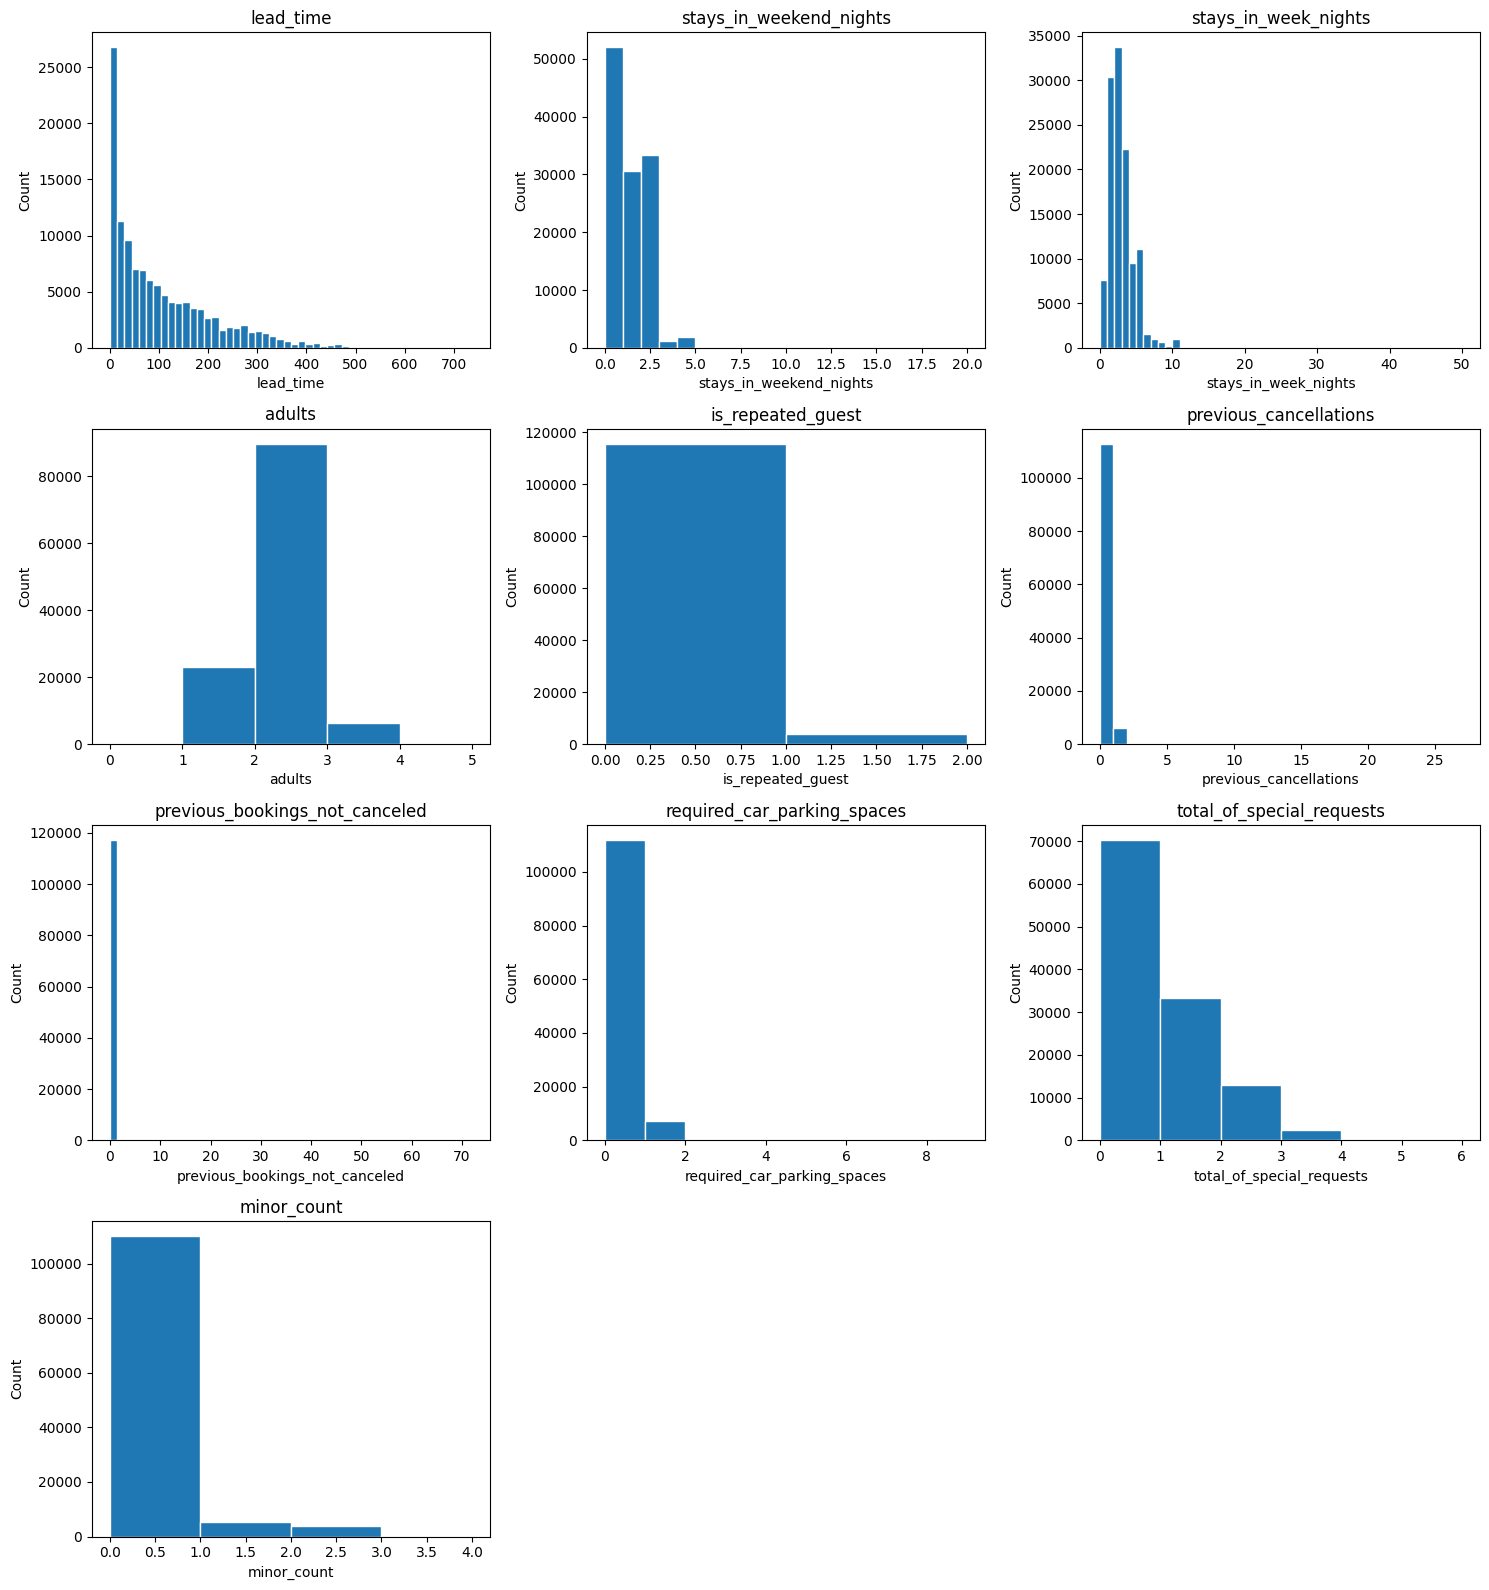

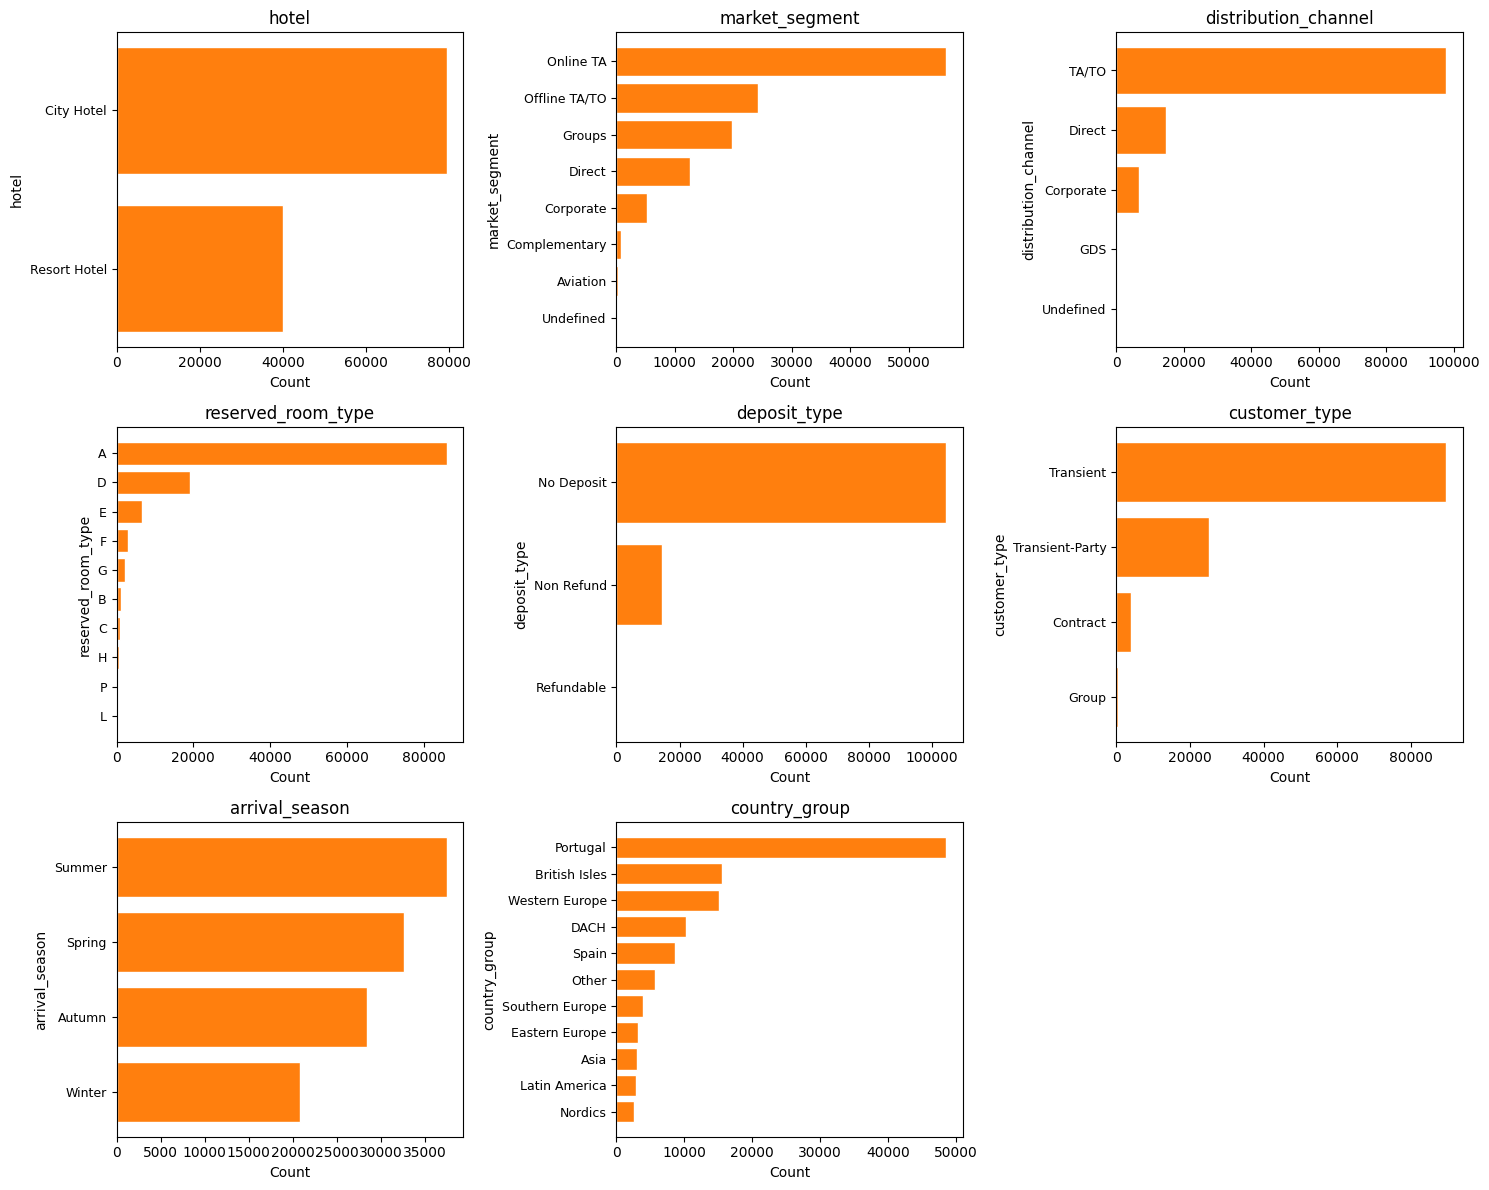

In [15]:
import matplotlib.pyplot as plt

if "num_features" not in globals():
    num_features = X.select_dtypes(include="number").columns.tolist()
if "cat_features" not in globals():
    cat_features = X.select_dtypes(exclude="number").columns.tolist()

hist_features = num_features
n_cols = 3
n_rows = (len(hist_features) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.ravel()

for ax, feature in zip(axes, hist_features):
    values = X[feature].dropna()
    unique_values = values.nunique()
    if unique_values <= 20:
        bins = range(int(values.min()), int(values.max()) + 2)
    else:
        bins = 50

    ax.hist(values, bins=bins, edgecolor="white")
    ax.set_title(feature)
    ax.set_xlabel(feature)
    ax.set_ylabel("Count")

for ax in axes[len(hist_features):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

cat_plot_features = cat_features
top_n = 15
n_rows = (len(cat_plot_features) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.ravel()

for ax, feature in zip(axes, cat_plot_features):
    values = X[feature].fillna("Missing").astype(str)
    counts = values.value_counts().head(top_n).sort_values()
    unique_values = values.nunique()
    title = feature if unique_values <= top_n else f"{feature} (top {top_n})"

    ax.barh(counts.index, counts.values, color="tab:orange", edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel("Count")
    ax.set_ylabel(feature)
    ax.tick_params(axis="y", labelsize=9)

for ax in axes[len(cat_plot_features):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


## End-to-End Preprocessing Pipeline
- Numeric features are split into regular and strongly right-skewed groups.
- Skewed features are log-transformed inside the preprocessing pipeline, while the raw engineered dataframe is kept for easier interpretation of cluster profiles.
- Categorical features are one-hot encoded with a minimum frequency threshold to avoid exploding the representation.


In [16]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler, RobustScaler

num_features = X.select_dtypes(include="number").columns.tolist()
cat_features = X.select_dtypes(exclude="number").columns.tolist()

skewed_num_features = [
    "lead_time",
    "previous_cancellations",
    "previous_bookings_not_canceled",
]
regular_num_features = [c for c in num_features if c not in skewed_num_features]

def build_preprocessor(scaler_cls):
    regular_numeric_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", scaler_cls()),
    ])

    skewed_numeric_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
        ("scaler", scaler_cls()),
    ])

    categorical_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=0.01, sparse_output=False)),
    ])

    return ColumnTransformer(
        transformers=[
            ("num_regular", regular_numeric_pipeline, regular_num_features),
            ("num_skewed", skewed_numeric_pipeline, skewed_num_features),
            ("cat", categorical_pipeline, cat_features),
        ],
        remainder="drop",
    )

representation_id = "R0-EUCLID-standard-noADR-countryGroup-minorCount"
representation_metric_sentence = (
    "Euclidean distance on the final transformed noADR booking matrix, "
    "with log1p-transformed skewed numerics, scaled numeric features, and full one-hot encoded categoricals."
)

preprocessor = build_preprocessor(StandardScaler)
X_prepared = preprocessor.fit_transform(X)
feature_names = preprocessor.get_feature_names_out()

print("Representation ID:", representation_id)
print("Metric sentence:", representation_metric_sentence)
print("Raw clustering matrix:", X.shape)
print("Prepared clustering matrix:", X_prepared.shape)
print("Regular numerical features:", regular_num_features)
print("Skewed numerical features (log1p in preprocessing):", skewed_num_features)
print("Categorical features:", cat_features)
print("Example transformed names:", feature_names[:25])


Representation ID: R0-EUCLID-standard-noADR-countryGroup-minorCount
Metric sentence: Euclidean distance on the final transformed noADR booking matrix, with log1p-transformed skewed numerics, scaled numeric features, and full one-hot encoded categoricals.
Raw clustering matrix: (119390, 18)
Prepared clustering matrix: (119390, 50)
Regular numerical features: ['stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'is_repeated_guest', 'required_car_parking_spaces', 'total_of_special_requests', 'minor_count']
Skewed numerical features (log1p in preprocessing): ['lead_time', 'previous_cancellations', 'previous_bookings_not_canceled']
Categorical features: ['hotel', 'market_segment', 'distribution_channel', 'reserved_room_type', 'deposit_type', 'customer_type', 'arrival_season', 'country_group']
Example transformed names: ['num_regular__stays_in_weekend_nights'
 'num_regular__stays_in_week_nights' 'num_regular__adults'
 'num_regular__is_repeated_guest'
 'num_regular__required_car_park

## Histogram of `log1p(lead_time)`
- This diagnostic plot shows the transformed shape actually used in preprocessing for `lead_time`.


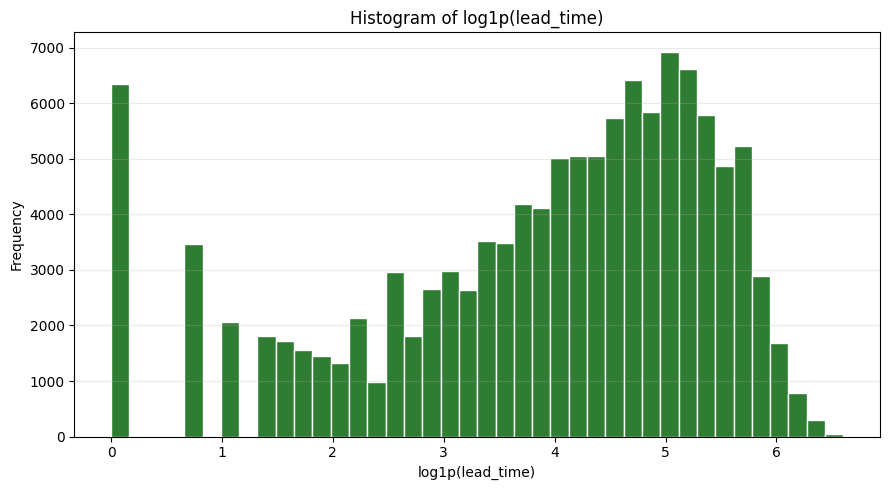

In [17]:
lead_time_log = np.log1p(X["lead_time"].dropna())

plt.figure(figsize=(9, 5))
plt.hist(lead_time_log, bins=40, color="#2E7D32", edgecolor="white")
plt.title("Histogram of log1p(lead_time)")
plt.xlabel("log1p(lead_time)")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


## Final Representation Declaration
- The main clustering matrix is explicitly named `R0-EUCLID-standard-noADR-countryGroup-minorCount`.
- All baseline and extension methods are run on the same Euclidean representation unless a cell is explicitly labelled as a preprocessing/representation sensitivity comparison.
- This makes the comparison between k-means and iKMeans methodologically consistent.


In [18]:
representation_summary = pd.DataFrame([
    {
        "representation_id": representation_id,
        "segmentation_time": "booking creation",
        "adr_in_inputs": False,
        "numeric_scaler": "StandardScaler",
        "rare-country-strategy": "Portugal and Spain separated; North America, Middle East, Africa, Oceania, and Unknown merged into Other",
        "family-feature-strategy": "minor_count = children + babies",
        "distance_metric": "Euclidean",
        "matrix_shape": str(X_prepared.shape),
    }
])
display(representation_summary)


,representation_id,segmentation_time,adr_in_inputs,numeric_scaler,rare-country-strategy,family-feature-strategy,distance_metric,matrix_shape
0,R0-EUCLID-standard-noADR-countryGroup-minorCount,booking creation,False,StandardScaler,"Portugal and Spain separated; North America, M...",minor_count = children + babies,Euclidean,"(119390, 50)"


## K-means Baselines and iK-means Evaluation (Same Protocol)



In [19]:
import time
from datetime import datetime

import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from iKMeans import ikmeans_initialize

K_RANGE = [3, 4, 5, 6, 7, 8]
RANDOM_STATES = [7, 21, 42, 84, 123]
IKM_MIN_CLUSTER_SIZE = 10

SIL_SAMPLE_SIZE = min(20000, X_prepared.shape[0])
rng = np.random.default_rng(42)
sample_idx = rng.choice(X_prepared.shape[0], size=SIL_SAMPLE_SIZE, replace=False)
X_eval = X_prepared[sample_idx]

rows = []

# 1) KMeans baseline
for k in K_RANGE:
    for seed in RANDOM_STATES:
        model = KMeans(n_clusters=k, random_state=seed, n_init=20, max_iter=300)
        t0 = time.perf_counter()
        labels_full = model.fit_predict(X_prepared)
        fit_elapsed = time.perf_counter() - t0

        labels_eval = labels_full[sample_idx]
        rows.append({
            "timestamp_utc": datetime.utcnow().isoformat(timespec="seconds"),
            "model": "kmeans",
            "k": k,
            "seed": seed,
            "init_seconds": 0.0,
            "fit_seconds": round(fit_elapsed, 4),
            "total_seconds": round(fit_elapsed, 4),
            "inertia": float(model.inertia_),
            "silhouette": float(silhouette_score(X_eval, labels_eval, metric="euclidean")),
            "calinski_harabasz": float(calinski_harabasz_score(X_eval, labels_eval)),
            "davies_bouldin": float(davies_bouldin_score(X_eval, labels_eval)),
            "min_cluster_share": float(pd.Series(labels_full).value_counts(normalize=True).min()),
            "ikm_extracted_clusters": np.nan,
        })

# 2) iKMeans initialization + downstream KMeans (same metrics protocol)
ikm_t0 = time.perf_counter()
ap_clusters, _init_std = ikmeans_initialize(
    X_prepared.astype(np.float64),
    min_cluster_size=IKM_MIN_CLUSTER_SIZE,
    tol=1e-12,
    max_iter=10_000,
    use_unit_ranges=False,
)
ikm_init_elapsed = time.perf_counter() - ikm_t0

ikm_retained = [c for c in ap_clusters if c.size >= IKM_MIN_CLUSTER_SIZE]
ikm_init_raw = np.vstack([c.centroid_raw for c in ikm_retained])
ikm_k = ikm_init_raw.shape[0]

ikm_model = KMeans(n_clusters=ikm_k, init=ikm_init_raw, n_init=1, max_iter=300, random_state=42)
fit_t0 = time.perf_counter()
ikm_labels_full = ikm_model.fit_predict(X_prepared)
ikm_fit_elapsed = time.perf_counter() - fit_t0

ikm_labels_eval = ikm_labels_full[sample_idx]
rows.append({
    "timestamp_utc": datetime.utcnow().isoformat(timespec="seconds"),
    "model": "ikmeans",
    "k": int(ikm_k),
    "seed": -1,
    "init_seconds": round(ikm_init_elapsed, 4),
    "fit_seconds": round(ikm_fit_elapsed, 4),
    "total_seconds": round(ikm_init_elapsed + ikm_fit_elapsed, 4),
    "inertia": float(ikm_model.inertia_),
    "silhouette": float(silhouette_score(X_eval, ikm_labels_eval, metric="euclidean")),
    "calinski_harabasz": float(calinski_harabasz_score(X_eval, ikm_labels_eval)),
    "davies_bouldin": float(davies_bouldin_score(X_eval, ikm_labels_eval)),
    "min_cluster_share": float(pd.Series(ikm_labels_full).value_counts(normalize=True).min()),
    "ikm_extracted_clusters": int(len(ap_clusters)),
})

results = pd.DataFrame(rows)
summary = results.groupby(["model", "k"], as_index=False).agg(
    runs=("model", "count"),
    silhouette_mean=("silhouette", "mean"),
    silhouette_std=("silhouette", "std"),
    calinski_mean=("calinski_harabasz", "mean"),
    davies_mean=("davies_bouldin", "mean"),
    inertia_mean=("inertia", "mean"),
    init_seconds_mean=("init_seconds", "mean"),
    fit_seconds_mean=("fit_seconds", "mean"),
    total_seconds_mean=("total_seconds", "mean"),
    min_cluster_share_mean=("min_cluster_share", "mean"),
)

ikm_cluster_sizes = pd.Series(ikm_labels_full).value_counts().sort_index().rename("size")

display(summary.sort_values(["model", "silhouette_mean"], ascending=[True, False]))
print("iKMeans extracted clusters (before min-size filtering):", len(ap_clusters))
print("iKMeans retained k:", ikm_k)
display((ikm_cluster_sizes / ikm_cluster_sizes.sum() * 100).round(2).rename("cluster_share_pct").to_frame())


,model,k,runs,silhouette_mean,silhouette_std,calinski_mean,davies_mean,inertia_mean,init_seconds_mean,fit_seconds_mean,total_seconds_mean,min_cluster_share_mean
0,ikmeans,47,1,0.110410,NaN,708.235988,2.215802,6.403320e+05,18.9031,1.04750,19.95060,0.004850
6,kmeans,8,5,0.138340,0.000013,2239.347945,1.688834,9.412995e+05,0.0000,4.08714,4.08714,0.030463
5,kmeans,7,5,0.132429,0.002888,2233.293180,1.748933,1.005999e+06,0.0000,4.08354,4.08354,0.031145
4,kmeans,6,5,0.129870,0.010199,2230.612886,1.816166,1.078492e+06,0.0000,3.73946,3.73946,0.031780
2,kmeans,4,5,0.122861,0.000317,2332.863334,2.029489,1.240274e+06,0.0000,2.92016,2.92016,0.033567
3,kmeans,5,5,0.122190,0.003388,2253.369147,1.934129,1.156540e+06,0.0000,3.23118,3.23118,0.033482
1,kmeans,3,5,0.111725,0.000336,2362.986310,2.325536,1.347121e+06,0.0000,2.30376,2.30376,0.034025


iKMeans extracted clusters (before min-size filtering): 47
iKMeans retained k: 47


,cluster_share_pct
0,0.68
1,2.86
2,1.44
3,4.36
4,2.25
5,1.94
6,4.27
7,1.60
8,1.25
9,1.61


## Representation Robustness: StandardScaler vs RobustScaler
- Following the milestone guidance, we compare the main `noADR` representation under `StandardScaler` and `RobustScaler`.
- The objective is to test whether the discovered profiles are mainly driven by heavy tails or extreme values.
- The comparison below uses the same `K_RANGE`, seeds, metrics and Euclidean setup as the main experiments.


In [20]:
from sklearn.metrics import adjusted_rand_score

representation_variants = [
    ("R0-EUCLID-standard-noADR-countryGroup-minorCount", StandardScaler),
    ("R1-EUCLID-robust-noADR-countryGroup-minorCount", RobustScaler),
]

representation_rows = []
representation_matrices = {}

for rep_label, scaler_cls in representation_variants:
    rep_preprocessor = build_preprocessor(scaler_cls)
    X_rep = rep_preprocessor.fit_transform(X)
    representation_matrices[rep_label] = X_rep
    X_rep_eval = X_rep[sample_idx]

    for k in K_RANGE:
        for seed in RANDOM_STATES:
            model = KMeans(n_clusters=k, random_state=seed, n_init=20, max_iter=300)
            labels_full = model.fit_predict(X_rep)
            labels_eval = labels_full[sample_idx]
            representation_rows.append({
                "representation": rep_label,
                "k": k,
                "seed": seed,
                "silhouette": float(silhouette_score(X_rep_eval, labels_eval, metric="euclidean")),
                "calinski_harabasz": float(calinski_harabasz_score(X_rep_eval, labels_eval)),
                "davies_bouldin": float(davies_bouldin_score(X_rep_eval, labels_eval)),
                "min_cluster_share": float(pd.Series(labels_full).value_counts(normalize=True).min()),
            })

representation_sensitivity = pd.DataFrame(representation_rows)
representation_sensitivity_summary = representation_sensitivity.groupby(["representation", "k"], as_index=False).agg(
    runs=("seed", "count"),
    silhouette_mean=("silhouette", "mean"),
    silhouette_std=("silhouette", "std"),
    calinski_mean=("calinski_harabasz", "mean"),
    davies_mean=("davies_bouldin", "mean"),
    min_cluster_share_mean=("min_cluster_share", "mean"),
)
display(representation_sensitivity_summary.sort_values(["representation", "silhouette_mean"], ascending=[True, False]))

ari_rows = []
for k in K_RANGE:
    labels_standard = KMeans(n_clusters=k, random_state=42, n_init=20, max_iter=300).fit_predict(representation_matrices[representation_variants[0][0]])
    labels_robust = KMeans(n_clusters=k, random_state=42, n_init=20, max_iter=300).fit_predict(representation_matrices[representation_variants[1][0]])
    ari_rows.append({
        "k": k,
        "ari_standard_vs_robust": float(adjusted_rand_score(labels_standard, labels_robust)),
    })
representation_ari = pd.DataFrame(ari_rows)
display(representation_ari)

representation_sensitivity_summary.to_csv("representation_sensitivity_summary.csv", index=False)
representation_ari.to_csv("representation_sensitivity_ari.csv", index=False)
print("Exported: representation_sensitivity_summary.csv, representation_sensitivity_ari.csv")


,representation,k,runs,silhouette_mean,silhouette_std,calinski_mean,davies_mean,min_cluster_share_mean
5,R0-EUCLID-standard-noADR-countryGroup-minorCount,8,5,0.138340,0.000013,2239.347945,1.688834,0.030463
4,R0-EUCLID-standard-noADR-countryGroup-minorCount,7,5,0.132429,0.002888,2233.293180,1.748933,0.031145
3,R0-EUCLID-standard-noADR-countryGroup-minorCount,6,5,0.129870,0.010199,2230.612886,1.816166,0.031780
1,R0-EUCLID-standard-noADR-countryGroup-minorCount,4,5,0.122861,0.000317,2332.863334,2.029489,0.033567
2,R0-EUCLID-standard-noADR-countryGroup-minorCount,5,5,0.122190,0.003388,2253.369147,1.934129,0.033482
0,R0-EUCLID-standard-noADR-countryGroup-minorCount,3,5,0.111725,0.000336,2362.986310,2.325536,0.034025
8,R1-EUCLID-robust-noADR-countryGroup-minorCount,5,5,0.123024,0.000057,1993.374831,2.174370,0.119507
7,R1-EUCLID-robust-noADR-countryGroup-minorCount,4,5,0.122544,0.000014,2195.202254,2.248084,0.144910
10,R1-EUCLID-robust-noADR-countryGroup-minorCount,7,5,0.120624,0.002228,1684.188801,2.181340,0.036586
9,R1-EUCLID-robust-noADR-countryGroup-minorCount,6,5,0.120344,0.001115,1852.121026,2.220263,0.115578


,k,ari_standard_vs_robust
0,3,0.171520
1,4,0.238341
2,5,0.422150
3,6,0.275286
4,7,0.164603
5,8,0.240637


Exported: representation_sensitivity_summary.csv, representation_sensitivity_ari.csv


## Selection of K



In [21]:
kmeans_summary = summary[summary["model"] == "kmeans"].copy()
MIN_CLUSTER_SHARE = 0.01


share_rows = []
for k in K_RANGE:
    model_tmp = KMeans(n_clusters=k, random_state=42, n_init=20, max_iter=300)
    labels_tmp = model_tmp.fit_predict(X_prepared)
    min_share = pd.Series(labels_tmp).value_counts(normalize=True).min()
    share_rows.append({"k": k, "min_cluster_share": float(min_share)})
share_df = pd.DataFrame(share_rows)

selection_df = kmeans_summary.merge(share_df, on="k", how="left")
feasible = selection_df[selection_df["min_cluster_share"] >= MIN_CLUSTER_SHARE].copy()

if not feasible.empty:
    chosen_pool = feasible
    guardrail_msg = "Guardrail satisfied."
else:
    chosen_pool = selection_df
    guardrail_msg = "No k satisfies min-cluster-share guardrail; fallback to best silhouette."

chosen_pool = chosen_pool.sort_values(["silhouette_mean", "calinski_mean", "davies_mean"], ascending=[False, False, True])
selected_k = int(chosen_pool.iloc[0]["k"])

final_model = KMeans(n_clusters=selected_k, random_state=42, n_init=20, max_iter=300)
final_labels = final_model.fit_predict(X_prepared)
cluster_share = pd.Series(final_labels).value_counts(normalize=True).sort_index()

print(guardrail_msg)
print("Selected model: KMeans")
print("Selected k:", selected_k)
print("Min cluster share (%):", round(cluster_share.min() * 100, 2))
display(selection_df.sort_values("k"))
display((cluster_share * 100).rename("cluster_share_pct").to_frame())


Guardrail satisfied.
Selected model: KMeans
Selected k: 8
Min cluster share (%): 3.05


,model,k,runs,silhouette_mean,silhouette_std,calinski_mean,davies_mean,inertia_mean,init_seconds_mean,fit_seconds_mean,total_seconds_mean,min_cluster_share_mean,min_cluster_share
0,kmeans,3,5,0.111725,0.000336,2362.986310,2.325536,1.347121e+06,0.0,2.30376,2.30376,0.034025,0.034031
1,kmeans,4,5,0.122861,0.000317,2332.863334,2.029489,1.240274e+06,0.0,2.92016,2.92016,0.033567,0.033571
2,kmeans,5,5,0.122190,0.003388,2253.369147,1.934129,1.156540e+06,0.0,3.23118,3.23118,0.033482,0.033487
3,kmeans,6,5,0.129870,0.010199,2230.612886,1.816166,1.078492e+06,0.0,3.73946,3.73946,0.031780,0.033403
4,kmeans,7,5,0.132429,0.002888,2233.293180,1.748933,1.005999e+06,0.0,4.08354,4.08354,0.031145,0.030756
5,kmeans,8,5,0.138340,0.000013,2239.347945,1.688834,9.412995e+05,0.0,4.08714,4.08714,0.030463,0.030463


,cluster_share_pct
0,31.743865
1,15.729961
2,6.819667
3,22.034509
4,3.046319
5,10.600553
6,4.766731
7,5.258397


## Initial Cluster Interpretation and Post-hoc Profiling
- Show full cluster tables without pandas truncation.
- Build a compact cluster summary that combines cluster size, key numerical signals, dominant categorical patterns, and post-hoc business indicators.
- Export the resulting tables to CSV so they can be inspected outside the notebook and reused in the written report.


In [22]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)

profile_df = X.copy()
profile_df["cluster"] = final_labels

cluster_size = (profile_df["cluster"].value_counts(normalize=True).sort_index() * 100).round(2)
cluster_size_df = cluster_size.rename("cluster_share_pct").to_frame()
display(cluster_size_df)

numeric_profile = profile_df.groupby("cluster")[num_features].mean().round(2)
display(numeric_profile)

cat_profile_rows = []
for c in cat_features:
    top = (profile_df.groupby("cluster")[c]
           .agg(lambda s: s.value_counts(normalize=True).index[0]))
    top_pct = (profile_df.groupby("cluster")[c]
               .agg(lambda s: round(100 * s.value_counts(normalize=True).iloc[0], 2)))
    for cl in top.index:
        cat_profile_rows.append({
            "cluster": int(cl),
            "feature": c,
            "top_category": top.loc[cl],
            "top_category_pct": top_pct.loc[cl],
        })

cat_profile = pd.DataFrame(cat_profile_rows).sort_values(["cluster", "feature"]).reset_index(drop=True)
display(cat_profile)

posthoc_df = df[posthoc_only].copy()
posthoc_df["cluster"] = final_labels

posthoc_numeric = posthoc_df.groupby("cluster").agg(
    adr_mean=("adr", "mean"),
    adr_median=("adr", "median"),
    cancellation_rate_pct=("is_canceled", lambda s: round(100 * s.mean(), 2)),
).round(2)
display(posthoc_numeric)

meal_profile = (posthoc_df.groupby("cluster")["meal"]
                .agg(lambda s: s.value_counts(normalize=True).index[0])
                .rename("top_meal"))
meal_profile_pct = (posthoc_df.groupby("cluster")["meal"]
                    .agg(lambda s: round(100 * s.value_counts(normalize=True).iloc[0], 2))
                    .rename("top_meal_pct"))
meal_profile_df = pd.concat([meal_profile, meal_profile_pct], axis=1)
display(meal_profile_df)

dominant_features = [
    "hotel",
    "market_segment",
    "distribution_channel",
    "deposit_type",
    "customer_type",
    "arrival_season",
    "country_group",
]

cluster_summary = cluster_size_df.join(numeric_profile).join(posthoc_numeric).join(meal_profile_df)
for feature in dominant_features:
    feature_slice = (cat_profile[cat_profile["feature"] == feature]
                     .set_index("cluster")[["top_category", "top_category_pct"]]
                     .rename(columns={
                         "top_category": f"{feature}_top",
                         "top_category_pct": f"{feature}_top_pct",
                     }))
    cluster_summary = cluster_summary.join(feature_slice)

cluster_summary = cluster_summary.sort_index()
display(cluster_summary)

numeric_profile.to_csv("cluster_numeric_profile.csv")
cat_profile.to_csv("cluster_categorical_profile.csv", index=False)
posthoc_numeric.to_csv("cluster_posthoc_profile.csv")
meal_profile_df.to_csv("cluster_meal_profile.csv")
cluster_summary.to_csv("cluster_summary.csv")

print("Exported: cluster_numeric_profile.csv, cluster_categorical_profile.csv, cluster_posthoc_profile.csv, cluster_meal_profile.csv, cluster_summary.csv")


,cluster_share_pct
cluster,
0,31.74
1,15.73
2,6.82
3,22.03
4,3.05
5,10.60
6,4.77
7,5.26


,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,required_car_parking_spaces,total_of_special_requests,minor_count
cluster,,,,,,,,,,
0,153.28,0.72,2.13,1.84,0.00,0.00,0.00,0.00,0.09,0.00
1,9.48,0.50,1.44,1.48,0.00,0.00,0.02,0.00,0.32,0.01
2,89.36,1.07,2.74,1.95,0.00,0.00,0.00,0.06,0.92,1.49
3,86.51,0.89,2.33,2.13,0.00,0.00,0.00,0.00,1.39,0.00
4,14.09,0.42,1.36,1.32,0.95,0.37,4.18,0.17,0.66,0.03
5,140.04,2.45,6.03,1.94,0.00,0.00,0.01,0.00,0.53,0.02
6,218.74,0.69,2.02,1.85,0.05,1.57,0.05,0.00,0.11,0.00
7,57.18,0.85,2.30,1.94,0.00,0.00,0.04,1.01,0.82,0.10


,cluster,feature,top_category,top_category_pct
0,0,arrival_season,Spring,32.40
1,0,country_group,Portugal,50.25
2,0,customer_type,Transient,61.52
3,0,deposit_type,No Deposit,72.31
4,0,distribution_channel,TA/TO,91.08
5,0,hotel,City Hotel,83.45
6,0,market_segment,Offline TA/TO,35.47
7,0,reserved_room_type,A,88.54
8,1,arrival_season,Winter,30.95
9,1,country_group,Portugal,47.62


,adr_mean,adr_median,cancellation_rate_pct
cluster,,,
0,93.64,90.00,52.60
1,88.26,85.00,17.76
2,156.85,151.07,38.04
3,116.40,110.86,28.31
4,63.14,65.00,7.45
5,98.42,85.84,35.37
6,77.12,68.00,99.53
7,111.18,100.50,0.00


,top_meal,top_meal_pct
cluster,,
0,BB,75.57
1,BB,81.28
2,BB,82.52
3,BB,76.02
4,BB,91.81
5,BB,67.59
6,BB,81.83
7,BB,81.81


,cluster_share_pct,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,required_car_parking_spaces,total_of_special_requests,minor_count,adr_mean,adr_median,cancellation_rate_pct,top_meal,top_meal_pct,hotel_top,hotel_top_pct,market_segment_top,market_segment_top_pct,distribution_channel_top,distribution_channel_top_pct,deposit_type_top,deposit_type_top_pct,customer_type_top,customer_type_top_pct,arrival_season_top,arrival_season_top_pct,country_group_top,country_group_top_pct
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,31.74,153.28,0.72,2.13,1.84,0.00,0.00,0.00,0.00,0.09,0.00,93.64,90.00,52.60,BB,75.57,City Hotel,83.45,Offline TA/TO,35.47,TA/TO,91.08,No Deposit,72.31,Transient,61.52,Spring,32.40,Portugal,50.25
1,15.73,9.48,0.50,1.44,1.48,0.00,0.00,0.02,0.00,0.32,0.01,88.26,85.00,17.76,BB,81.28,City Hotel,61.03,Online TA,40.47,TA/TO,56.69,No Deposit,98.52,Transient,77.50,Winter,30.95,Portugal,47.62
2,6.82,89.36,1.07,2.74,1.95,0.00,0.00,0.00,0.06,0.92,1.49,156.85,151.07,38.04,BB,82.52,City Hotel,61.15,Online TA,75.19,TA/TO,82.49,No Deposit,99.90,Transient,91.08,Summer,48.89,Portugal,26.85
3,22.03,86.51,0.89,2.33,2.13,0.00,0.00,0.00,0.00,1.39,0.00,116.40,110.86,28.31,BB,76.02,City Hotel,77.35,Online TA,89.00,TA/TO,94.15,No Deposit,99.97,Transient,89.90,Summer,34.63,Western Europe,20.87
4,3.05,14.09,0.42,1.36,1.32,0.95,0.37,4.18,0.17,0.66,0.03,63.14,65.00,7.45,BB,91.81,Resort Hotel,50.48,Corporate,44.16,Corporate,47.04,No Deposit,98.63,Transient,86.39,Spring,30.77,Portugal,84.00
5,10.60,140.04,2.45,6.03,1.94,0.00,0.00,0.01,0.00,0.53,0.02,98.42,85.84,35.37,BB,67.59,Resort Hotel,78.67,Online TA,44.88,TA/TO,85.96,No Deposit,97.65,Transient,73.17,Summer,44.20,British Isles,37.79
6,4.77,218.74,0.69,2.02,1.85,0.05,1.57,0.05,0.00,0.11,0.00,77.12,68.00,99.53,BB,81.83,City Hotel,85.36,Groups,58.39,TA/TO,93.34,Non Refund,63.12,Transient,50.64,Autumn,41.57,Portugal,95.77
7,5.26,57.18,0.85,2.30,1.94,0.00,0.00,0.04,1.01,0.82,0.10,111.18,100.50,0.00,BB,81.81,Resort Hotel,75.23,Online TA,54.59,TA/TO,64.27,No Deposit,99.71,Transient,85.92,Summer,32.18,Portugal,37.08


Exported: cluster_numeric_profile.csv, cluster_categorical_profile.csv, cluster_posthoc_profile.csv, cluster_meal_profile.csv, cluster_summary.csv
